# 02 — Demographic Forecasting
> Population forecast for children aged 0–6 by district (2024–2034) using ETS, Prophet, and Ensemble.

---

## Setup

In [ ]:
from math import sqrt
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing

sys.path.insert(0, str(Path("../src").resolve()))

from config import POPULATION_FILE as INPUT_PATH, POPULATION_FORECAST_FILE as OUTPUT_PATH

## 1. Data Loading

Load the historical district-level population series for children aged 0–6 and prepare the forecast frame.
The initial chart provides a quick sanity check on the observed trends before modeling.

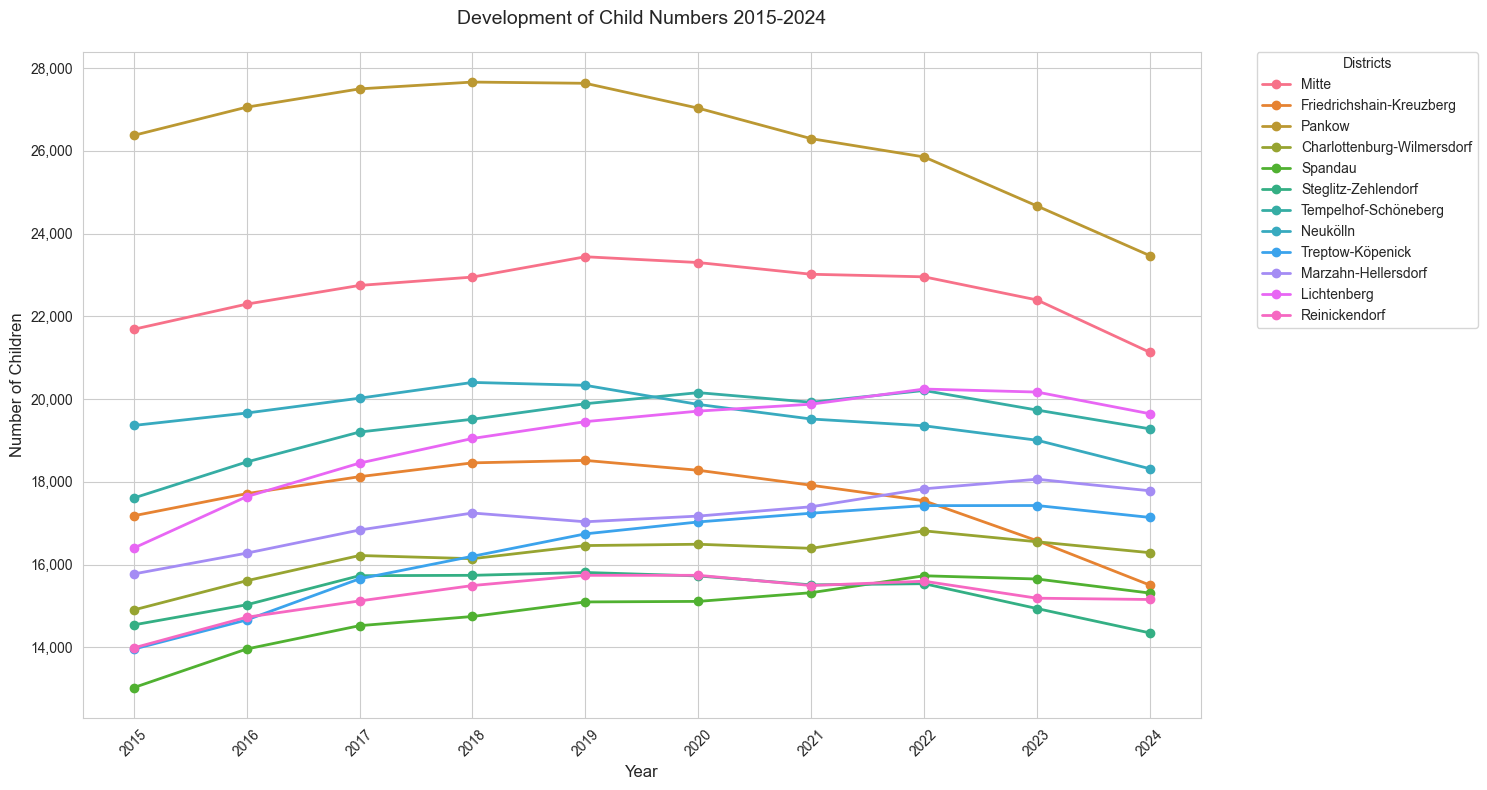


Results DataFrame Structure:
                             2024 2029 2034
Bezirk                                     
Mitte                       21130  NaN  NaN
Friedrichshain-Kreuzberg    15504  NaN  NaN
Pankow                      23466  NaN  NaN
Charlottenburg-Wilmersdorf  16288  NaN  NaN
Spandau                     15312  NaN  NaN
Steglitz-Zehlendorf         14349  NaN  NaN
Tempelhof-Schöneberg        19281  NaN  NaN
Neukölln                    18317  NaN  NaN
Treptow-Köpenick            17140  NaN  NaN
Marzahn-Hellersdorf         17784  NaN  NaN
Lichtenberg                 19646  NaN  NaN
Reinickendorf               15157  NaN  NaN


In [3]:
df = pd.read_csv(INPUT_PATH)
year_columns = [str(year) for year in range(2015, 2025)]
df = df[['Bezirk'] + year_columns]

plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

colors = sns.color_palette("husl", n_colors=len(df))

for idx, row in df.iterrows():
    district = row['Bezirk']
    values = row[year_columns].values
    plt.plot(year_columns, values, marker='o', label=district, color=colors[idx], linewidth=2)

plt.title('Development of Child Numbers 2015-2024', fontsize=14, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Children', fontsize=12)
plt.xticks(rotation=45)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.0,
    title='Districts',
    frameon=True,
)

plt.tight_layout()
plt.show()

# Create results DataFrame with districts as index and forecast years as columns
forecast_years = [2024, 2029, 2034]
results = pd.DataFrame(index=df['Bezirk'], columns=forecast_years)

# Fill in 2024 values
results[2024] = df['2024'].values

print("\nResults DataFrame Structure:")
print(results)

### Error metrics and evaluation helpers

Define a few standard forecast error metrics and a shared evaluation helper.
These values are reused for ETS, Prophet, and the ensemble comparison.

In [4]:
def calculate_rmse(y_true, y_pred):
    return sqrt(mean_squared_error(y_true, y_pred))


def calculate_mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)


def calculate_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


def evaluate_model(model_name, y_true, y_pred, bezirk):
    return {
        'Model': model_name,
        'Bezirk': bezirk,
        'RMSE': calculate_rmse(y_true, y_pred),
        'MAE': calculate_mae(y_true, y_pred),
        'MAPE': calculate_mape(y_true, y_pred)
    }

In [5]:
# Define forecast years
forecast_years = [2029, 2034]

# Initialize DataFrame for all predictions
all_predictions = pd.DataFrame(
    index=df['Bezirk'],
    columns=[
        f'{model}_{year}' 
        for model in ['ETS', 'Prophet', 'Ensemble'] 
        for year in forecast_years
    ]
)

evaluation_results = []

### Exponential Smoothing

Fit an ETS model for each district, store the forecast years, and evaluate the holdout fit on the last two observed values.

In [6]:
# Exponential Smoothing for each district
for district in df['Bezirk']:
    # Prepare historical data - now in correct chronological order
    historical_values = df[df['Bezirk'] == district][year_columns].values.flatten()
    
    # Train-Test-Split for evaluation
    train_data = historical_values[:-2]
    test_data = historical_values[-2:]
    
    # Exponential Smoothing forecast
    exp_model = ExponentialSmoothing(
        historical_values, trend='add', seasonal=None, damped_trend=True
    ).fit()
    exp_forecast = exp_model.forecast(16)
    
    # Save the ETS forecasts
    for i, year in enumerate(forecast_years):
        all_predictions.loc[district, f'ETS_{year}'] = np.round(exp_forecast[4 + i*5], 0)
    
    # Evaluation
    exp_model_eval = ExponentialSmoothing(
        train_data, trend='add', seasonal=None, damped_trend=True
    ).fit()
    exp_pred_eval = exp_model_eval.forecast(2)
    evaluation_results.append(
        evaluate_model('Exponential Smoothing', test_data, exp_pred_eval, district)
    )

# Display results for ETS
print("\nExponential Smoothing forecasts:")
print(all_predictions.filter(like='ETS'))
print("\nETS Evaluation:")
ets_eval = pd.DataFrame(evaluation_results)
print(ets_eval.groupby('Model')[['RMSE', 'MAE', 'MAPE']].mean())


Exponential Smoothing forecasts:
                           ETS_2029 ETS_2034
Bezirk                                      
Mitte                       20567.0  20000.0
Friedrichshain-Kreuzberg    14171.0  12896.0
Pankow                      21427.0  19566.0
Charlottenburg-Wilmersdorf  17425.0  18024.0
Spandau                     17022.0  18075.0
Steglitz-Zehlendorf         13916.0  13497.0
Tempelhof-Schöneberg        19616.0  19803.0
Neukölln                    17352.0  16450.0
Treptow-Köpenick            18523.0  19815.0
Marzahn-Hellersdorf         19110.0  20066.0
Lichtenberg                 19551.0  19509.0
Reinickendorf               15218.0  15256.0

ETS Evaluation:
                             RMSE        MAE      MAPE
Model                                                 
Exponential Smoothing  735.412781  676.52866  3.778959


### Prophet

Fit a Prophet model per district and evaluate it on the same short holdout window used for ETS.
This keeps the comparison consistent across forecasting approaches.

In [7]:
# Prophet for each district
for district in df['Bezirk']:
    # Extract historical data - and flatten() to make it 1-dimensional
    historical_values = df[df['Bezirk'] == district][year_columns].values.flatten()
    
    # Create date range
    dates = pd.date_range(start='2015', periods=len(year_columns), freq='Y')
    
    # Prepare data for Prophet
    prophet_df = pd.DataFrame({
        'ds': dates,
        'y': historical_values
    })
    
    # Fit model and make forecast
    prophet_model = Prophet(yearly_seasonality=False)
    prophet_model.fit(prophet_df)
    
    # Create future data
    future = pd.DataFrame({
        'ds': [pd.Timestamp(str(year)) for year in forecast_years]
    })
    prophet_forecast = prophet_model.predict(future)
    
    # Extract forecasts for the desired years
    for year in forecast_years:
        forecast_value = prophet_forecast[prophet_forecast['ds'].dt.year == year]['yhat'].values[0]
        all_predictions.loc[district, f'Prophet_{year}'] = np.round(forecast_value, 0)
    
    # Evaluation
    train_data = historical_values[:-2]
    test_data = historical_values[-2:]
    
    # Prepare evaluation dataset
    train_dates = dates[:-2]
    prophet_df_eval = pd.DataFrame({
        'ds': train_dates,
        'y': train_data
    })
    
    # Fit evaluation model
    prophet_model_eval = Prophet(yearly_seasonality=False)
    prophet_model_eval.fit(prophet_df_eval)
    
    # Forecast for evaluation period
    future_eval = pd.DataFrame({'ds': dates[-2:]})
    prophet_pred_eval = prophet_model_eval.predict(future_eval)['yhat'].values
    
    evaluation_results.append(
        evaluate_model('Prophet', test_data, prophet_pred_eval, district)
    )

# Display results for Prophet
print("\nProphet forecasts:")
print(all_predictions.filter(like='Prophet'))
print("\nProphet Evaluation:")
prophet_eval = pd.DataFrame(evaluation_results)
print(prophet_eval[prophet_eval['Model'] == 'Prophet'].groupby('Model')[['RMSE', 'MAE', 'MAPE']].mean())

09:43:11 - cmdstanpy - INFO - Chain [1] start processing
09:43:11 - cmdstanpy - INFO - Chain [1] done processing
09:43:11 - cmdstanpy - INFO - Chain [1] start processing
09:43:11 - cmdstanpy - INFO - Chain [1] done processing
09:43:11 - cmdstanpy - INFO - Chain [1] start processing
09:43:11 - cmdstanpy - INFO - Chain [1] done processing
09:43:11 - cmdstanpy - INFO - Chain [1] start processing
09:43:11 - cmdstanpy - INFO - Chain [1] done processing
09:43:11 - cmdstanpy - INFO - Chain [1] start processing
09:43:11 - cmdstanpy - INFO - Chain [1] done processing
09:43:11 - cmdstanpy - INFO - Chain [1] start processing
09:43:11 - cmdstanpy - INFO - Chain [1] done processing
09:43:11 - cmdstanpy - INFO - Chain [1] start processing
09:43:11 - cmdstanpy - INFO - Chain [1] done processing
09:43:11 - cmdstanpy - INFO - Chain [1] start processing
09:43:11 - cmdstanpy - INFO - Chain [1] done processing
09:43:12 - cmdstanpy - INFO - Chain [1] start processing
09:43:12 - cmdstanpy - INFO - Chain [1]


Prophet forecasts:
                           Prophet_2029 Prophet_2034
Bezirk                                              
Mitte                           17963.0      13787.0
Friedrichshain-Kreuzberg        16134.0      15280.0
Pankow                          18696.0      12736.0
Charlottenburg-Wilmersdorf      15721.0      14928.0
Spandau                         15010.0      14490.0
Steglitz-Zehlendorf             11967.0       8995.0
Tempelhof-Schöneberg            17718.0      15724.0
Neukölln                        16620.0      14380.0
Treptow-Köpenick                16676.0      16022.0
Marzahn-Hellersdorf             18648.0      19462.0
Lichtenberg                     18781.0      17564.0
Reinickendorf                   14434.0      13570.0

Prophet Evaluation:
               RMSE         MAE      MAPE
Model                                    
Prophet  669.250873  601.149788  3.371532


### Ensemble

Combine ETS and Prophet forecasts with weights derived from their mean MAPE.
The ensemble serves as the final forecast written to the output table.

In [8]:
# Method 3: Ensemble

# Calculate weights based on the performance (MAPE) of the models
ets_mape = ets_eval[ets_eval['Model'] == 'Exponential Smoothing']['MAPE'].mean()
prophet_mape = prophet_eval[prophet_eval['Model'] == 'Prophet']['MAPE'].mean()

# Use inverse MAPE for weighting
ets_weight = (1/ets_mape) / (1/ets_mape + 1/prophet_mape)
prophet_weight = (1/prophet_mape) / (1/ets_mape + 1/prophet_mape)

# Ensemble for each district
for district in df['Bezirk']:
    # Extract historical data in correct order
    historical_values = df[df['Bezirk'] == district][year_columns].values.flatten()
    dates = pd.date_range(start='2015', periods=len(year_columns), freq='Y')
    
    # Calculate ensemble forecast and save
    for year in forecast_years:
        ets_pred = all_predictions.loc[district, f'ETS_{year}']
        prophet_pred = all_predictions.loc[district, f'Prophet_{year}']
        ensemble_pred = (ets_weight * ets_pred + prophet_weight * prophet_pred)
        all_predictions.loc[district, f'Ensemble_{year}'] = np.round(ensemble_pred, 0)
    
    # Evaluation
    train_data = historical_values[:-2]
    test_data = historical_values[-2:]
    
    # ETS Evaluation
    exp_model_eval = ExponentialSmoothing(
        train_data, trend='add', seasonal=None, damped_trend=True
    ).fit()
    ets_pred_eval = exp_model_eval.forecast(2)
    
    # Prophet Evaluation
    train_dates = dates[:-2]
    prophet_df_eval = pd.DataFrame({
        'ds': train_dates,
        'y': train_data
    })
    prophet_model_eval = Prophet(yearly_seasonality=False)
    prophet_model_eval.fit(prophet_df_eval)
    future_eval = pd.DataFrame({'ds': dates[-2:]})
    prophet_pred_eval = prophet_model_eval.predict(future_eval)['yhat'].values
    
    # Ensemble Evaluation
    ensemble_pred_eval = ets_weight * ets_pred_eval + prophet_weight * prophet_pred_eval
    
    evaluation_results.append(
        evaluate_model('Ensemble', test_data, ensemble_pred_eval, district)
    )

# Display results for Ensemble
print("\nEnsemble forecasts:")
print(all_predictions.filter(like='Ensemble'))
print("\nEnsemble Evaluation:")
ensemble_eval = pd.DataFrame(evaluation_results)
print(ensemble_eval[ensemble_eval['Model'] == 'Ensemble'].groupby('Model')[['RMSE', 'MAE', 'MAPE']].mean())

# Transfer final Ensemble forecasts to results DataFrame
for year in forecast_years:
    if year == 2024:
        continue  # 2024 we already have from real data
    results[year] = all_predictions[f'Ensemble_{year}']

09:43:14 - cmdstanpy - INFO - Chain [1] start processing
09:43:14 - cmdstanpy - INFO - Chain [1] done processing
09:43:14 - cmdstanpy - INFO - Chain [1] start processing
09:43:14 - cmdstanpy - INFO - Chain [1] done processing
09:43:14 - cmdstanpy - INFO - Chain [1] start processing
09:43:14 - cmdstanpy - INFO - Chain [1] done processing
09:43:14 - cmdstanpy - INFO - Chain [1] start processing
09:43:14 - cmdstanpy - INFO - Chain [1] done processing
09:43:14 - cmdstanpy - INFO - Chain [1] start processing
09:43:14 - cmdstanpy - INFO - Chain [1] done processing
09:43:14 - cmdstanpy - INFO - Chain [1] start processing
09:43:14 - cmdstanpy - INFO - Chain [1] done processing
09:43:15 - cmdstanpy - INFO - Chain [1] start processing
09:43:15 - cmdstanpy - INFO - Chain [1] done processing
09:43:15 - cmdstanpy - INFO - Chain [1] start processing
09:43:15 - cmdstanpy - INFO - Chain [1] done processing
09:43:15 - cmdstanpy - INFO - Chain [1] start processing
09:43:15 - cmdstanpy - INFO - Chain [1]


Ensemble forecasts:
                           Ensemble_2029 Ensemble_2034
Bezirk                                                
Mitte                            19191.0       16716.0
Friedrichshain-Kreuzberg         15208.0       14156.0
Pankow                           19984.0       15956.0
Charlottenburg-Wilmersdorf       16524.0       16388.0
Spandau                          15959.0       16180.0
Steglitz-Zehlendorf              12886.0       11118.0
Tempelhof-Schöneberg             18613.0       17647.0
Neukölln                         16965.0       15356.0
Treptow-Köpenick                 17547.0       17810.0
Marzahn-Hellersdorf              18866.0       19747.0
Lichtenberg                      19144.0       18481.0
Reinickendorf                    14804.0       14365.0

Ensemble Evaluation:
                RMSE         MAE      MAPE
Model                                     
Ensemble  699.433138  634.252971  3.550137


## Results / Summary

Review the aggregated model metrics and compare the best-performing model per district.
The ensemble output is then prepared for export.

In [9]:
# Convert Evaluation Results to DataFrame
eval_df = pd.DataFrame(evaluation_results)

# Average metrics per model
print("Average metrics per model:")
print(eval_df.groupby('Model')[['RMSE', 'MAE', 'MAPE']].mean())

# Best models per district based on MAPE
print("\nBest models per district (based on MAPE):")
best_models = eval_df.loc[eval_df.groupby('Bezirk')['MAPE'].idxmin()]
print(best_models[['Bezirk', 'Model', 'MAPE']])

Average metrics per model:
                             RMSE         MAE      MAPE
Model                                                  
Ensemble               699.433138  634.252971  3.550137
Exponential Smoothing  735.412781  676.528660  3.778959
Prophet                669.250873  601.149788  3.371532

Best models per district (based on MAPE):
                        Bezirk                  Model      MAPE
15  Charlottenburg-Wilmersdorf                Prophet  2.803515
13    Friedrichshain-Kreuzberg                Prophet  6.008396
22                 Lichtenberg                Prophet  3.458186
9          Marzahn-Hellersdorf  Exponential Smoothing  1.029205
12                       Mitte                Prophet  4.235415
19                    Neukölln                Prophet  1.402531
14                      Pankow                Prophet  3.443157
23               Reinickendorf                Prophet  1.874544
4                      Spandau  Exponential Smoothing  3.006928
17        

## Export

Final district forecasts are written to `data/processed/population_forecast_2024_2034.csv`.


Forecast saved in: ../data/processed/prognose_2024_2034.csv


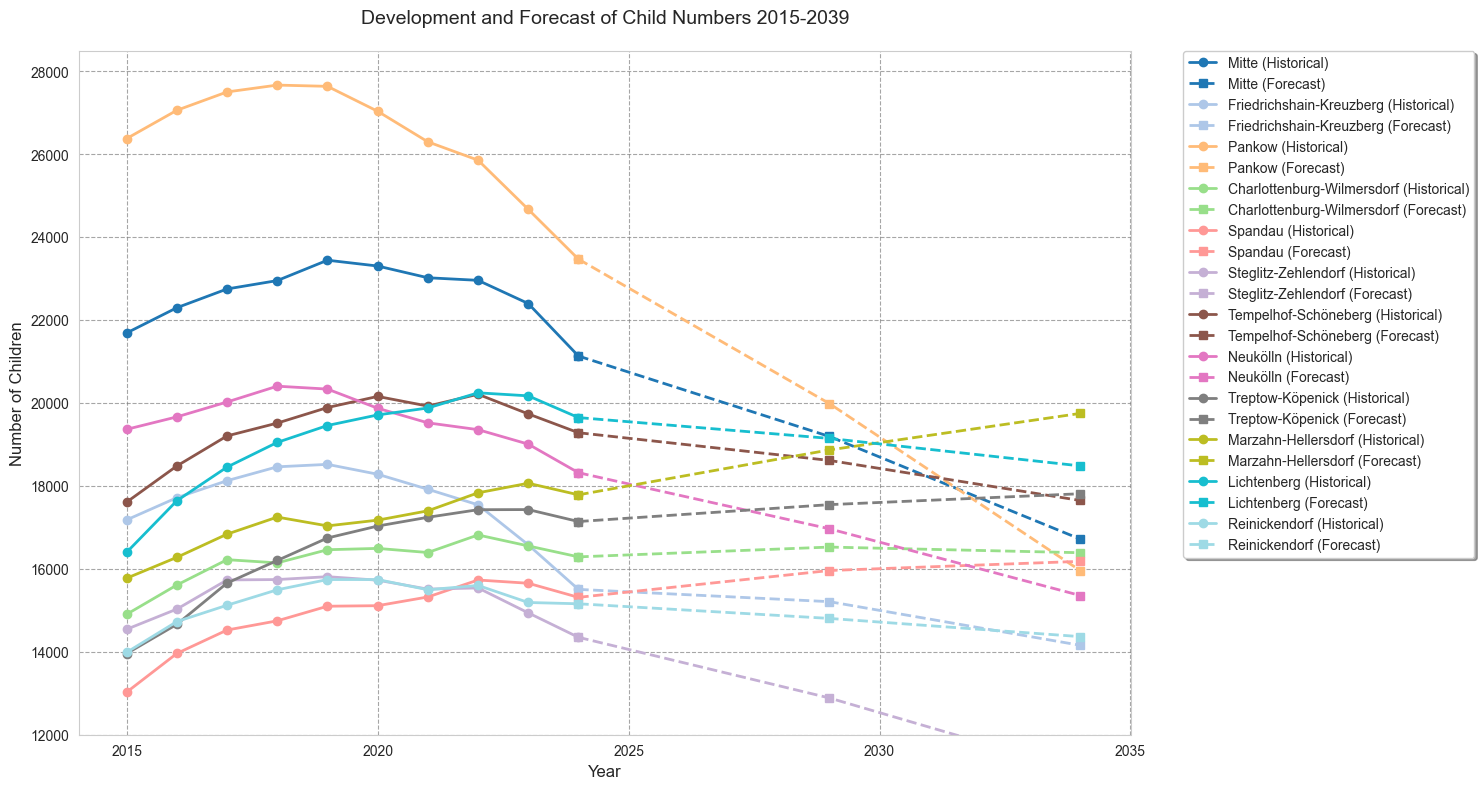

In [10]:
results = results.astype(int)

# Save results as CSV
results.to_csv(OUTPUT_PATH)

# Output the save path
print(f"\nForecast saved in: {OUTPUT_PATH}")

plt.figure(figsize=(15, 8))

# Define colors for each district
colors = plt.cm.tab20(np.linspace(0, 1, len(df['Bezirk'])))

# Plot historical data and forecasts for each district
for idx, bezirk in enumerate(df['Bezirk']):
        # Historical data
        historical_values = df[df['Bezirk'] == bezirk].iloc[0, 1:].values
        historical_years = list(range(2015, 2025))
        
        # Forecast values
        forecast_values = results.loc[bezirk]
        all_years = results.columns.astype(int)
        
        # Plot with the same color for historical and forecast
        plt.plot(historical_years, historical_values, 
                marker='o', 
                linestyle='-', 
                color=colors[idx],
                linewidth=2,
                label=f'{bezirk} (Historical)')
        
        plt.plot(all_years, forecast_values, 
                marker='s', 
                linestyle='--', 
                color=colors[idx],
                linewidth=2,
                label=f'{bezirk} (Forecast)')

plt.title('Development and Forecast of Child Numbers 2015-2039', pad=20, size=14)
plt.xlabel('Year', size=12)
plt.ylabel('Number of Children', size=12)

# Set x-axis ticks to show whole years
plt.xticks(range(2015, 2040, 5))  # Show years in 5-year intervals
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))

# Adjust grid
plt.grid(True, linestyle='--', alpha=0.7, color='gray', zorder=0)

# Adjust axis range
plt.ylim(bottom=12000)  # Adjust lower bound

# Optimize legend
plt.legend(bbox_to_anchor=(1.05, 1), 
                loc='upper left', 
                borderaxespad=0,
                frameon=True,
                fancybox=True,
                shadow=True,
                fontsize=10)

# Adjust layout
plt.tight_layout()
plt.show()